# **Extracción**

In [ ]:
# Importamos la librería principal para manipulación de datos
import pandas as pd

# 1. Definimos la URL de la API (enlace 'raw' del JSON en GitHub)
url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# 2. Cargamos los datos directamente desde la URL a un DataFrame de Pandas
df_crudo = pd.read_json(url_api)

# 3. Mostramos las primeras 5 filas para inspeccionar los encabezados y los datos
df_crudo.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#**Transformación y Limpieza de Datos (ETL)**

In [ ]:
import pandas as pd
import requests

# === 1. EXTRACCIÓN Y APLANAMIENTO ===
url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
respuesta = requests.get(url_api)
datos_json = respuesta.json()

# Usamos json_normalize para "aplanar" los datos anidados
df_crudo = pd.json_normalize(datos_json)

# === 2. TRANSFORMACIÓN ===
df_limpio = df_crudo.copy()

# A. Renombramos las columnas generadas por el aplanamiento y las pasamos al español
df_limpio.rename(columns={
    'customerID': 'ID_Cliente',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Facturacion_Electronica',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cobro_Mensual',
    'account.Charges.Total': 'Cobro_Total'
}, inplace=True)

# B. Corrección de Cobro_Total: Lo forzamos a número y eliminamos vacíos
df_limpio['Cobro_Total'] = pd.to_numeric(df_limpio['Cobro_Total'], errors='coerce')
df_limpio.dropna(subset=['Cobro_Total'], inplace=True)

# C. Creación de la columna Cuentas_Diarias
df_limpio['Cuentas_Diarias'] = round(df_limpio['Cobro_Mensual'] / 30, 2)

# D. Estandarización de Churn (Evasión) a formato binario (1 = Sí, 0 = No)
df_limpio['Churn_Binario'] = df_limpio['Churn'].map({'Yes': 1, 'No': 0})

print("¡Extracción y Limpieza terminadas! Tamaño del dataset:", df_limpio.shape)
# Mostramos las primeras 3 filas para verificar
display(df_limpio.head(3))

¡Extracción y Limpieza terminadas! Tamaño del dataset: (7256, 23)


,ID_Cliente,Churn,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cobro_Mensual,Cobro_Total,Cuentas_Diarias,Churn_Binario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0.0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0.0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1.0


#**Carga**

In [ ]:
# === CARGA (LOAD) ===
# Guardamos nuestro DataFrame limpio en un archivo CSV para no perder el progreso
df_limpio.to_csv('TelecomX_Limpio.csv', index=False)
print("¡Archivo guardado con éxito como 'TelecomX_Limpio.csv'!")

# === ANÁLISIS DESCRIPTIVO ===
# Usamos describe() para ver las métricas clave de nuestras variables numéricas
print("\n--- Estadísticas Descriptivas ---")
display(df_limpio[['Meses_Contrato', 'Cobro_Mensual', 'Cobro_Total', 'Cuentas_Diarias']].describe())

¡Archivo guardado con éxito como 'TelecomX_Limpio.csv'!

--- Estadísticas Descriptivas ---


,Meses_Contrato,Cobro_Mensual,Cobro_Total,Cuentas_Diarias
count,7256.000000,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213,2.158467
std,24.558067,30.125739,2268.632997,1.004282
min,1.000000,18.250000,18.800000,0.610000
25%,9.000000,35.450000,400.225000,1.180000
50%,29.000000,70.300000,1391.000000,2.340000
75%,55.000000,89.900000,3785.300000,3.000000
max,72.000000,118.750000,8684.800000,3.960000


#**Análisis Exploratorio de Datos**

/tmp/ipykernel_300/3577274273.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x='Churn', palette='pastel', ax=axes[0,0])
/tmp/ipykernel_300/3577274273.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn', y='Cobro_Mensual', palette='pastel', ax=axes[1,1])


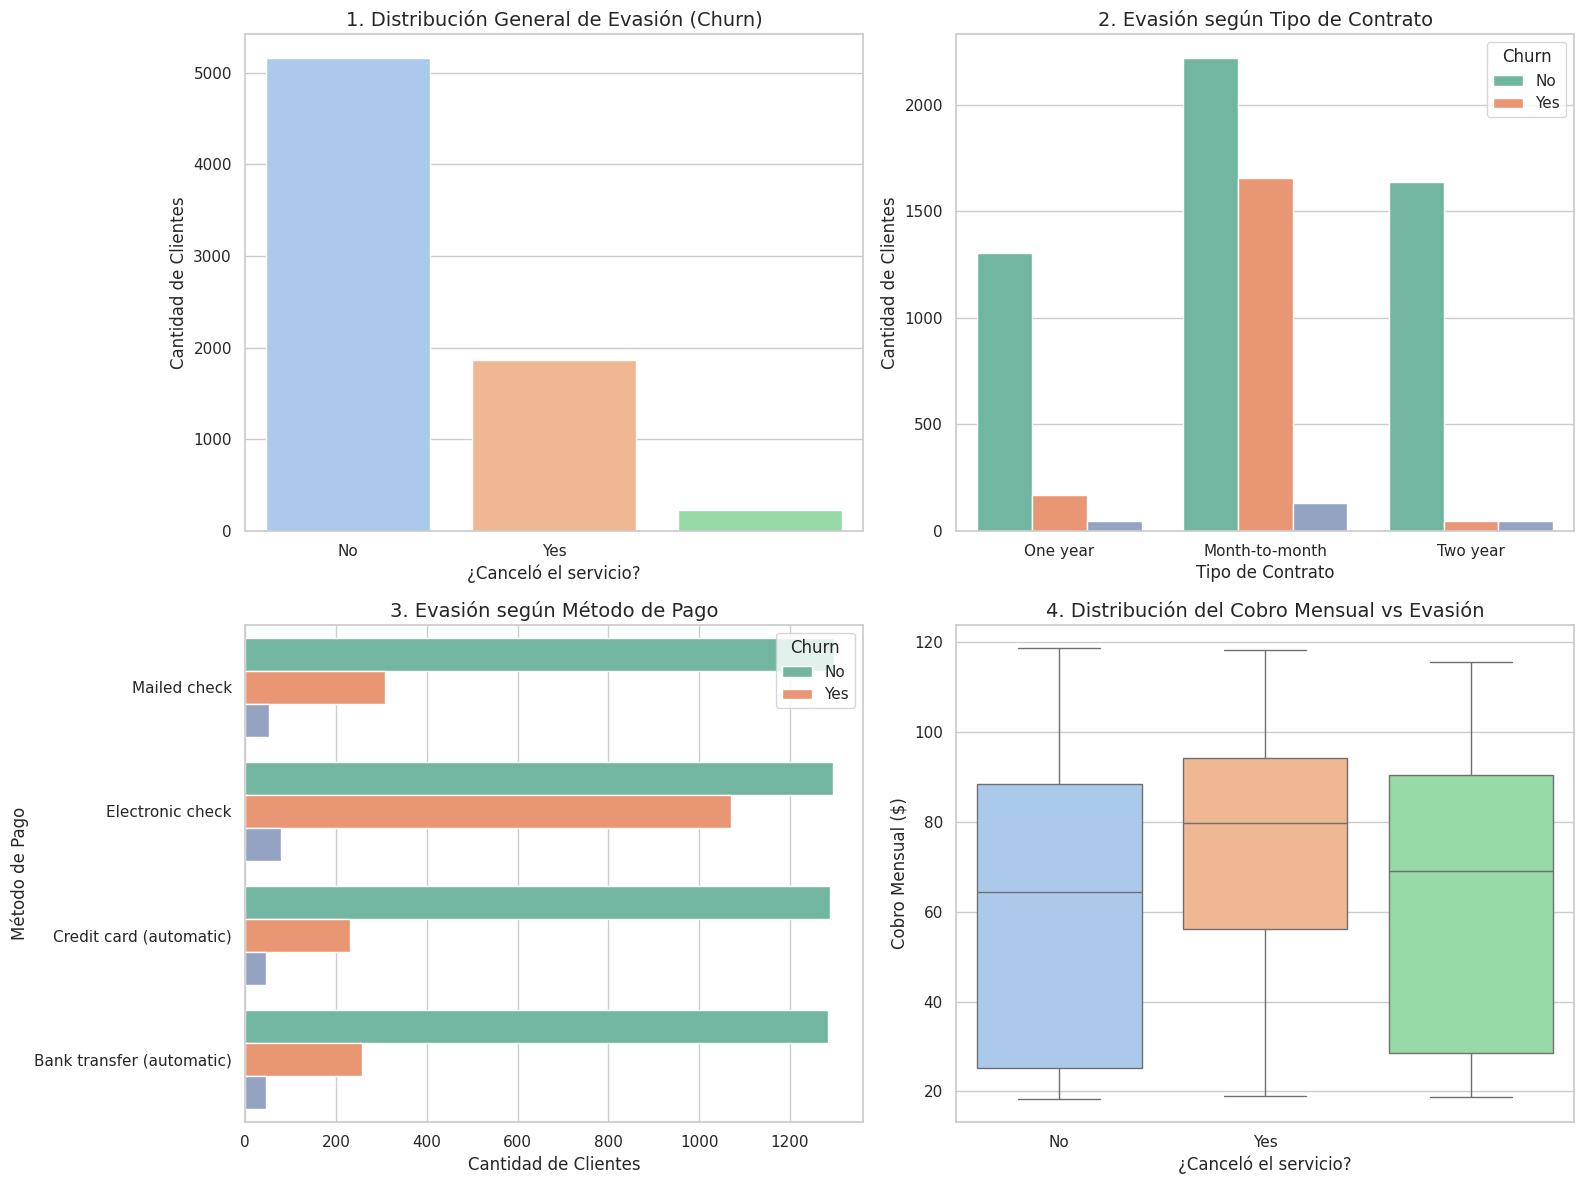

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Creamos un "lienzo" con 4 espacios (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de Evasión general (Churn)
sns.countplot(data=df_limpio, x='Churn', palette='pastel', ax=axes[0,0])
axes[0,0].set_title('1. Distribución General de Evasión (Churn)', fontsize=14)
axes[0,0].set_ylabel('Cantidad de Clientes')
axes[0,0].set_xlabel('¿Canceló el servicio?')

# 2. Evasión por Variable Categórica: Tipo de Contrato
sns.countplot(data=df_limpio, x='Tipo_Contrato', hue='Churn', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('2. Evasión según Tipo de Contrato', fontsize=14)
axes[0,1].set_xlabel('Tipo de Contrato')
axes[0,1].set_ylabel('Cantidad de Clientes')

# 3. Evasión por Variable Categórica: Método de Pago
sns.countplot(data=df_limpio, y='Metodo_Pago', hue='Churn', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('3. Evasión según Método de Pago', fontsize=14)
axes[1,0].set_ylabel('Método de Pago')
axes[1,0].set_xlabel('Cantidad de Clientes')

# 4. Evasión por Variable Numérica: Cobro Mensual (Boxplot)
sns.boxplot(data=df_limpio, x='Churn', y='Cobro_Mensual', palette='pastel', ax=axes[1,1])
axes[1,1].set_title('4. Distribución del Cobro Mensual vs Evasión', fontsize=14)
axes[1,1].set_xlabel('¿Canceló el servicio?')
axes[1,1].set_ylabel('Cobro Mensual ($)')

# Ajustamos el espacio y mostramos
plt.tight_layout()
plt.show()

#**Extra: Matriz de Correlación**

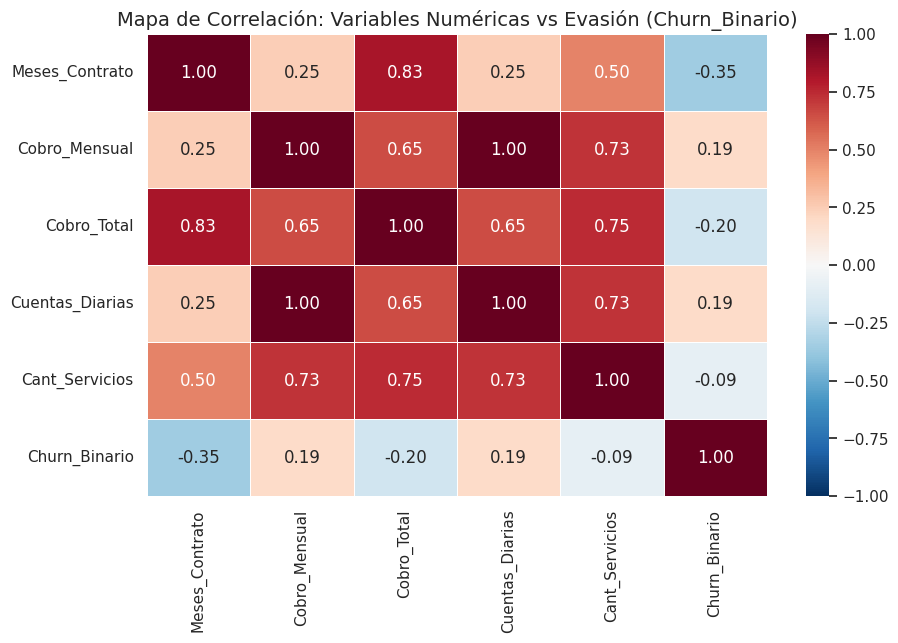

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Contar la cantidad de servicios adicionales contratados
servicios_adicionales = ['Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo',
                         'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']

# Sumamos cuántos "Yes" tiene cada cliente en esos servicios
df_limpio['Cant_Servicios'] = df_limpio[servicios_adicionales].apply(lambda x: (x == 'Yes').sum(), axis=1)

# 2. Seleccionamos solo las variables numéricas para la matriz
vars_numericas = ['Meses_Contrato', 'Cobro_Mensual', 'Cobro_Total', 'Cuentas_Diarias', 'Cant_Servicios', 'Churn_Binario']

# 3. Calculamos la correlación de Pearson
matriz_corr = df_limpio[vars_numericas].corr()

# 4. Graficamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Correlación: Variables Numéricas vs Evasión (Churn_Binario)', fontsize=14)
plt.show()